# **Análisis del crecimiento del Producto Interno Bruto mexicano**
  
El Producto Interno Bruto (PIB) es el indicador de la producción total de los bienes y servicios finales que produce un país en un periodo determinado. Su utilidad radica en que sirve para medir el comportamiento global de una economía.

El análisis busca responder a las siguientes preguntas:
1. ¿Cómo ha evolucionado el PIB?
2. ¿Cuánto ha crecido el PIB en el último trimestre registrado?
3. ¿Cómo ha sido el crecimiento del PIB en los últimos cinco años?

En cuanto a la serie desestacionalizada se busca:
1. ¿Cómo se compara la serie normal con la serie desestacionalizda?
2. ¿Cómo se comparan los crecimientos anuales?
3. ¿Cuánto ha crecido el PIB en su último trimestre respecto al trimestre anterior? 
4. ¿Cómo ha sido el crecimiento del PIB de los últimos 10 trimestres registrados?

Para el siguiente análisis las series a usar son el PIB trimestral a precios de 2018 (precios constantes) y el PIB trimestral a precios de 2018, serie desestacionalizada.


# **Fuente**

- **Serie original:**
    - Fuente: INEGI, Banco de Información Económica (BIE). PIB trimestral a precios de 2018, millones de pesos.

- **Serie desestacionalizada:**
    - Fuente: INEGI, Banco de Información Económica (BIE). PIB trimestral a precios de 2018, serie desestacionalizada, millones de pesos.

Ver `README.md` para el detalle completo de la consulta y notas metodológicas.

In [1]:
# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

In [2]:
# Cargar datos

pib_normal = pd.read_csv('../data/pib-precios-2018.csv')
pib_desest = pd.read_csv('../data/pib-precios-2018-desestacionalizada.csv')

# Mostrar datos serie original

pib_normal

,Periodos,PIB
0,1980/01,10401367.61
1,1980/02,10342350.00
2,1980/03,10392733.01
3,1980/04,10927666.35
4,1981/01,11345848.49
...,...,...
181,2025/02,25618678.77
182,2025/03,25422850.19
183,2025/04,26135644.70
184,2026/01,24963384.14


## Serie original

### 1. ¿Cómo ha evolucionado el PIB?

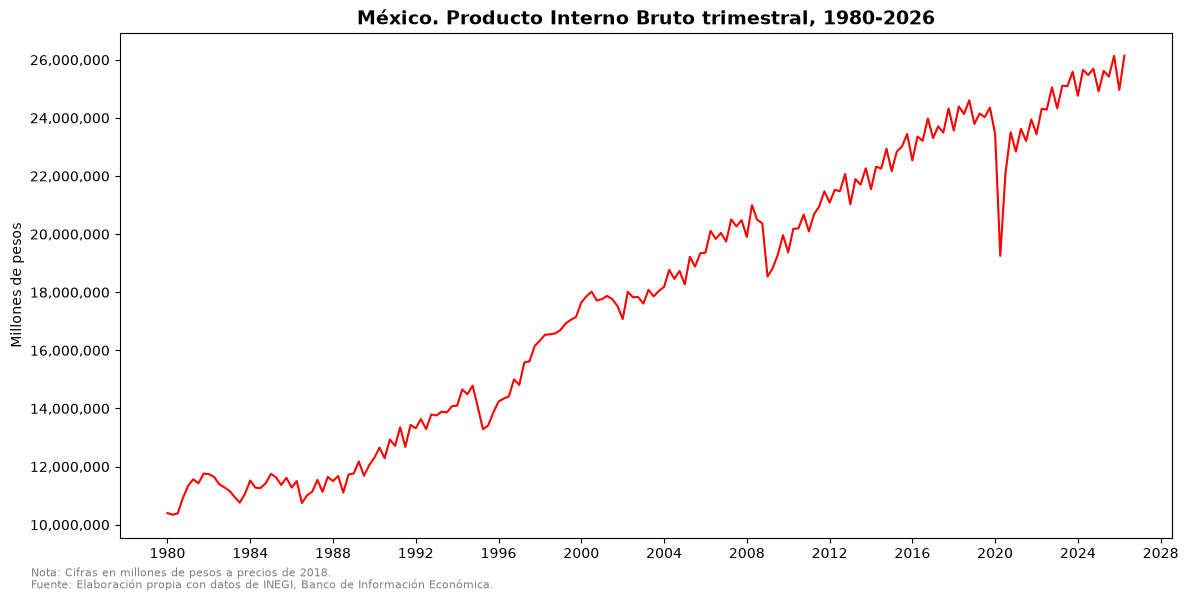

In [3]:
# Gráfica de la evolución del PIB

# 1. Preparación y conversión de los datos

pib_normal['fecha'] = pd.PeriodIndex(pib_normal['Periodos'].str.replace(r'(\d{4})/0?(\d)', r'\1Q\2', regex=True), freq='Q').to_timestamp()

# 2. Creación de la figura y gráfica

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pib_normal['fecha'], pib_normal['PIB'], color='red')

ax.set_title('México. Producto Interno Bruto trimestral, 1980-2026', fontsize=14, fontweight='bold')

# 3. Configuración de los ejes

# 3.1. Configuración del eje X

ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3.2. Configuración del eje Y

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
ax.set_ylabel('Millones de pesos')

# 4. Agregar fuente y notas metodológicas

fig.text(0.03, 0.01, 'Fuente: Elaboración propia con datos de INEGI, Banco de Información Económica.', fontsize=8, color='grey', ha='left')
fig.text(0.03, 0.03, 'Nota: Cifras en millones de pesos a precios de 2018.', fontsize=8, color='grey', ha='left')
plt.tight_layout(rect=[0, 0.03, 1, 1])

# 5. Guardar gráfica en directorio figures

plt.savefig('../figures/grafica_01_evolucion_pib.png', dpi=150, bbox_inches='tight')

# 6. Mostrar gráfica

plt.show()

La serie original del PIB muestra una evolución generalmente creciente a lo largo del periodo analizado, con fluctuaciones al alza y a la baja entre trimestres. En general, se observa una tendencia ascendente en el largo plazo.

Asimismo, se identifican cinco contracciones relevantes a lo largo de la serie, cuyos periodos son:
1. **Del segundo trimestre de 1982 al tercer trimestre de 1983:** la caída se relaciona con la crisis de la deuda externa. La caída de los precios del petróleo y el alza de las tasas de interés internacionales provocan la contracción económica, al volver insostenible el pago de la deuda externa.
2. **Del cuarto trimestre de 1994 al segundo trimestre de 1995:** la caída se relaciona con el llamado "Error de Diciembre" o "Efecto Tequila". La fuga de capitales, el agotamiento de las reservas internacionales y la devaluación del peso, provocan una profunda crisis económica.
3. **Del tercer trimestre de 2001 al primer trimestre de 2002:** la recesión se relaciona con la crisis "dot com" en Estados Unidos. La desaceleración de la economía estadounidense afecta la actividad económica del país.
4. **Del segundo trimestre de 2008 al primer trimestre de 2009:** la caída se relaciona con la crisis financiera global derivada del colapso de la burbuja inmobiliaria (hipotecas subprime) en Estados Unidos. México registra una recesión severa debido a su vinculación comercial y financiera con ese país.
5. **Del cuarto trimestre de 2019 al segundo trimestre de 2020:** la caída se relaciona con la contracción económica por la pandemia de COVID-19, derivada de la suspensión de actividades no esenciales. A esta caída le sigue una recuperación relativamente rápida, reflejada en los dos trimestres siguientes.

Tras esta última contracción y su rápida recuperación, el PIB mexicano regresa en 2022 a niveles similares a los prepandemia, retomando su tendencia ascendente.



### **2. Crecimiento interanual del último trimestre registrado (2T-2026)**

Se compara el mismo trimestre de años consecutivos (en lugar del trimestre inmediato anterior) para evitar el efecto de la estacionalidad, ya que la serie original no está desestacionalizada.

In [4]:
# Crecimiento interanual 2T-2026 vs 2T-2025

# 1. Filtrar los trimestres correspondientes

pib_inter = pib_normal.query('Periodos in ["2025/02", "2026/02"]')

# 2. Crear la columna "Crecimiento_%" y calcular el crecimiento interanual

pib_inter['Crecimiento_%'] = pib_inter['PIB'].pct_change().round(3) * 100

# 3. Mostrar los datos

pib_inter

,Periodos,PIB,fecha,Crecimiento_%
181,2025/02,25618678.77,2025-04-01,NaN
185,2026/02,26144132.44,2026-04-01,2.1


El PIB registra un crecimiento interanual de 2.1% en el segundo trimestre de 2026, respecto al segundo trimestre de 2025.

### **3. Crecimiento del PIB en los últimos cinco años (2020-2025)**

El PIB anual se calcula mediante el promedio simple de los cuatro trimestres del año (INEGI, *Lo que indican los indicadores*).

In [5]:
# Crecimiento del PIB en los últimos cinco años (2020-2025)

# 1. Función para calcular el PIB anual mediante el promedio de los trimestres

def calcular_pib_anual(año):
    
    # 1.1. Filtrar los registros correspondientes al año indicado
    
    pib_filtro = pib_normal[pib_normal['Periodos'].str.startswith(año)]
    
    # 1.2. Calcular el promedio del PIB trimestral para ese año
    
    pib_promedio = pib_filtro['PIB'].mean()
    
    return pib_promedio

# 2. Ejecutar la función para cada año seleccionado

# 2.1. Definir las listas de trabajo

lista_años = ["2020", "2021", "2022", "2023", "2024", "2025"]   # Años a analizar
resultdo_funcion = []   # Lista vacía que almacenará el resultado de cada año

# 2.2. Recorrer la lista de años y almacenar el PIB promedio de cada uno

for año in lista_años:
    resultdo_funcion.append(calcular_pib_anual(año))
    
# 3. Crear un nuevo DataFrame con los años y sus respectivos valores de PIB anual

pib_anual = pd.DataFrame({'Año': lista_años, 'PIB': resultdo_funcion})

# 4. Mostrar resultados

pib_anual

,Año,PIB
0,2020,2.206993e+07
1,2021,2.340483e+07
2,2022,2.427309e+07
3,2023,2.503103e+07
4,2024,2.539647e+07
5,2025,2.552270e+07
